In [ ]:
import typing 
import collections
import heapq
from typing import List, Optional
from collections import defaultdict, Counter, deque

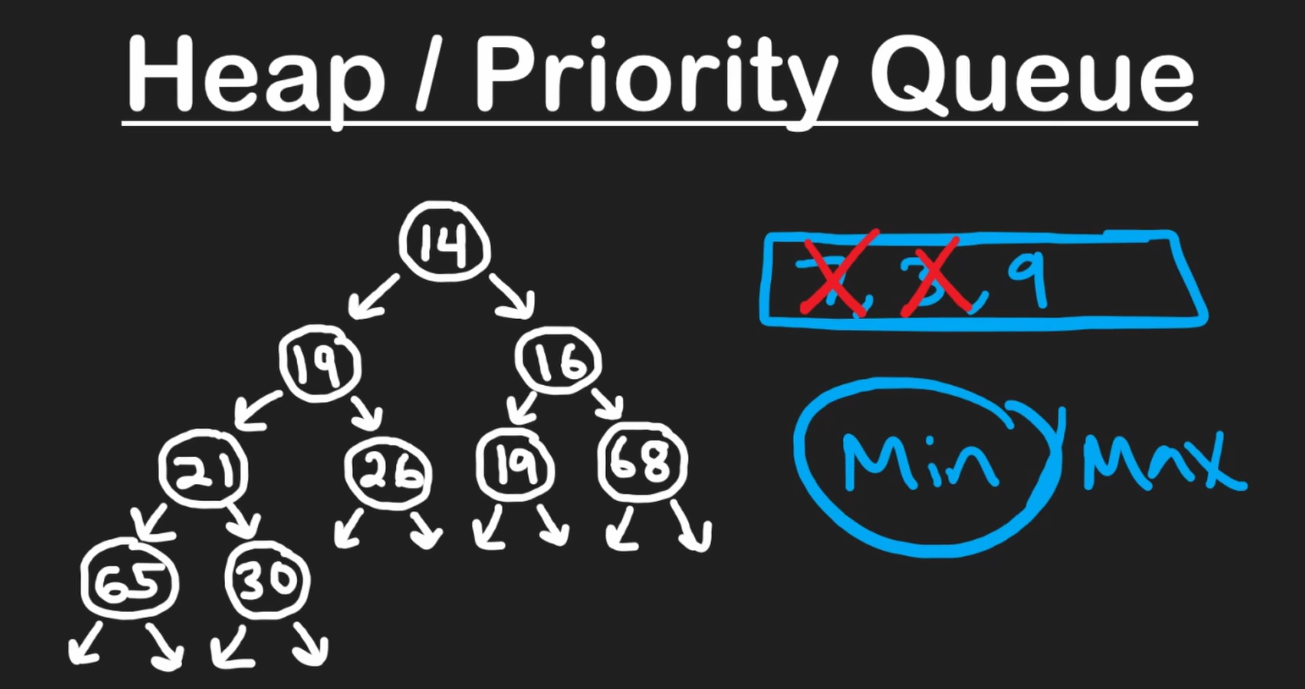

they are implemented using array (under the hood)

array :  `[x, 14, 19, 16, 21, 26, 19, 68, 65, 30]`
- left child = `2*i`
- right child = `2*i +1`
- parent = `i/2`

Its had property of :
1. Structure property - if no hole in level of the tree except last level (complete binary tree)
   1. value on the tree added left to right
2. Order property - each level from root, have bigger value 
   1. its a complete binary tree

heap can have duplicates:



| Operation | Time Complexity |
| --------- | --------------- |
| top()     | O(1)            |
| inset()   | O(log n)        |
| remove()  | O(log n)        |
| heapify() | O(n)            |
* adding value on heap in one go is `O(log n)`
* adding value on heap one a time (like thru some operations the value results) is `O(n*log n)`


In [ ]:
class Heap:
    
    def __init__(self):
        self.heap = [0]

    # take the value at last and perocolate to correct 
    def push(self, val):
        self.heap.append(val)
        i = len(self.heap) - 1
        
        # percolate up  ( value at index i should be less than i //2 (parent) then do a swap)
        while self.heap[i] < self.heap[i//2]:
            tmp = self.heap[i]
            self.heap[i] = self.heap[i//2]
            self.heap[i//2] = tmp
            i = i//2


    # appraoch: take the last node, move it to root and percolate down
    # TC: Log(n)
    def pop(self):
        if len(self.heap) == 1:
            return None
        
        if len(self.heap) == 2:
            return self.heap.pop()
        
        res = self.heap[1]

        # move last value to root
        self.heap[1] = self.heap.pop()
        i = 1
        
        # percolate down
        while 2 * i < len(self.heap):
            if (2*i + 1 < len(self.heap) and 
                self.heap[2*i + 1] < self.heap[2*i] and   # rightchild < left child 
                self.heap[i] > self.heap[2*i + 1]):       # parent > right child 
                
                # swap right child                     # swap smaller one to parent (which is right here)
                tmp = self.heap[i]
                self.heap[i] = self.heap[ 2*i + 1]
                self.heap[2*i + 1] = tmp
                i = 2*i + 1
                
            elif self.heap[i] > self.heap[2*i]:        # parent > left 
                # swap left child                     # swap left with parent
                tmp = self.heap[i]
                self.heap[i] = self.heap[2*i]
                self.heap[2*i] = tmp
            else:
                break
        return res


    # inn binary search tree, need to insert every single node 
    # min/max : O(1) in binary O(log(n))
    # insertion : O(log(n)) in binary O(n log(n))
    
    # heapify : O(n) = 
    def heapify(self, arr):
        #0-th position is moved to the end
        arr.append(arr[0])
        self.heap = arr
        
        cur = (len(self.heap)-1)//2 # we are taking the middle value but can take last value
        
        while cur > 0:
            
            # Percolate down
            i = cur  
            
            while 2*i < len(self.heap):
                if (2*i+1 < len(self.heap) and 
                    self.heap[2*i + 1] < len(self.heap[2*i]) and 
                    self.heap[i] > self.heap[2*i+1]):
                    
                    # swap right child
                    tmp = self.heap[i]
                    self.heap[i] = self.heap[2*i +1]
                    self.heap[2*i+1] = tmp
                    i = 2*i + 1
                
                elif self.heap[i] > self.heap[2*i]:
                    
                    # swap left child
                    tmp = self.head[i]
                    self.heap[i] = self.heap[2 * i]
                    self.heap[2*i] = tmp
                    i = 2 * i
                else:
                    break
            cur -= 1 

Time complexity to heapify
- 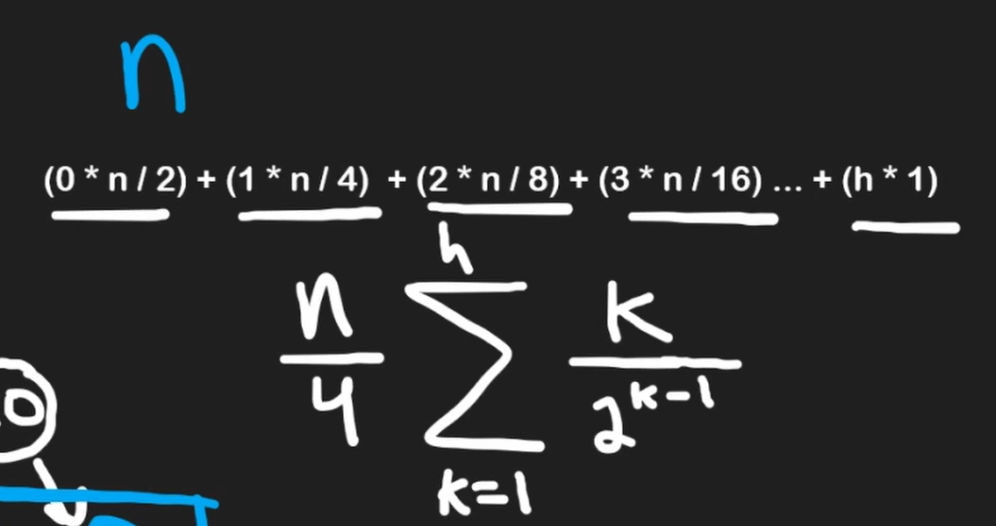

sorting willl take `O(nLog(n))`
- binary tree are not good for searching, 

In [ ]:
# Two heaps

# applied on medians (find median when those numbers are sorted)
# if sorting need to be done nlogn

# if we keep getting value 

# probem: implement a median finder, where new values are inserted into a set and have to get the median from that set


- small value maxHeap and large value minHeap
- 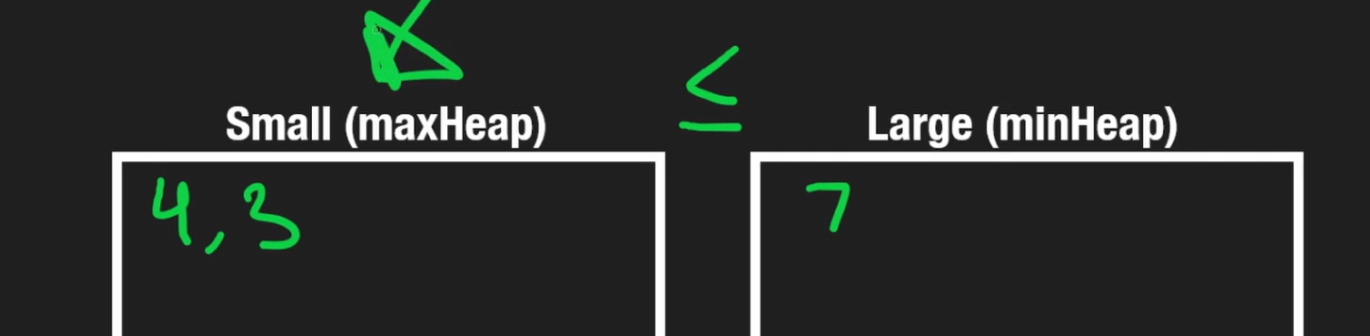
- the new value we insert might be you think need to compare with both heaps: heap1 and heap2 all values 
- if and elase willl be created bczo need to decide which heap should contain this
- so now, without that
- we can jsut insert the value to the left, and consider to heapify and compare the max value from maxheap, 
- then the length of both heaps if even - max value+minvalue / 2 and odd - min value

In [ ]:
import heapq 

In [ ]:
class Median:
    def __init__(self):
        self.small, self.large = [], []

    def insert(self, num: int) -> None:
        
        # push the max heap and swap with min heap if needed
        heapq.heappush(self.small, -1* num)
        if (self.small and self.large and (-1 * self.small[0]) > self.large[0]):
            val = -1 * heapq.heappop(self.num)
            heapq.heappush(self.large, val)
        
        # handle uneven size
        if len(self.small) > len(self.large) + 1:
            val = -1 * heapq.heappop(self.small)
            heapq.heappush(self.large, val)
        
        # 
        if len(self.large) > len(self.small) + 1:
            val = heapq.heappop(self.large)
            heapq.heappush(self.small, -1 * val)

    def getMedian(self) -> float:
        
        #  
        if len(self.small) > len(self.large):  # 
            return -1 * self.small[0]
        elif len(self.large) > len(self.small):
            return self.large[0]
        
        # even # of the elements, return avg of two middle nums
        return (-1 * self.small[0] + self.large[0] // 2)

In [ ]:
'''
Kth Largest Elemenet in a Stream
'''

class KthLargest:

    def __init__(self, k: int, nums: List[int]):
        self.k = k
        self.minHeap = nums
        heapq.heapify(self.minHeap)
        #  to get the min heap till kth
        while len(self.minHeap) > self.k:
            heapq.heappop(self.minHeap)

    def add(self, val: int) -> int:
        # added new value to to minheap
        heapq.heappush(self.minHeap, val) 
        # we remove this bcoz on minheap we added value
        if len(self.minHeap) > self.k:
            heapq.heappop(self.minHeap) 
        # minheap is basically an array to we return first value          
        return self.minHeap[0]

# Your KthLargest object will be instantiated and called as such:
# obj = KthLargest(k, nums)
# param_1 = obj.add(val)